# Load Data

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu, ttest_rel, wilcoxon
from scipy.stats import pearsonr, kendalltau
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Probit
from stargazer.stargazer import Stargazer

pd.set_option('display.max_columns', None)

In [3]:
ev = pd.read_excel('../../clean/evaluator_cleaned.xlsx')
dg = pd.read_excel('../../clean/delegator_cleaned.xlsx')

In [24]:
ev.time_taken.describe()

count     153.000000
mean      474.137255
std       228.406207
min       113.000000
25%       335.000000
50%       421.000000
75%       557.000000
max      1824.000000
Name: time_taken, dtype: float64

# Create Helper Functions and Variables

In [4]:
def calculate_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
    return pvalues

# Balance across observables

In [4]:
balance = []
for column in ['age', 'female', 'socio_status', 'went_to_uni', 'technology_score', 'tech_use_at_work_often', 'leader']:
    mean_treat_0 = ev[ev['treat'] == 0][column].mean()
    mean_treat_1 = ev[ev['treat'] == 1][column].mean()

    group_0 = ev[ev['treat'] == 0][column]
    group_1 = ev[ev['treat'] == 1][column]
    t_stat, p_value = ttest_ind(group_0, group_1, nan_policy='omit')

    balance.append([column, mean_treat_0, mean_treat_1, p_value])

balance = pd.DataFrame(balance, columns=['Variable', 'Mean if treat==0', 'Mean if treat==1', 'p-value'])
balance


,Variable,Mean if treat==0,Mean if treat==1,p-value
0,age,37.0875,42.356164,0.010285
1,female,0.5875,0.493151,0.244805
2,socio_status,5.4250,5.109589,0.201675
3,went_to_uni,0.6875,0.481481,0.007806
4,technology_score,1.3625,1.333333,0.868672
5,tech_use_at_work_often,0.6000,0.530864,0.379427
6,leader,0.2875,0.320988,0.646756


# Attention Check

In [26]:
ev.groupby('treat')['pass_att2'].value_counts()

treat  pass_att2
0      1            67
       0            13
1      1            68
       0            13
Name: pass_att2, dtype: int64

In [27]:
ev['punish_time'].describe(percentiles=[.10, .20, .30, .40, .50, .60, .70, .80, .90])

count    161.000000
mean     133.888199
std       77.363831
min       35.000000
10%       60.000000
20%       78.000000
30%       87.000000
40%       99.000000
50%      115.000000
60%      128.000000
70%      155.000000
80%      180.000000
90%      225.000000
max      514.000000
Name: punish_time, dtype: float64

In [28]:
#Do subjects for whom the punishmnet is hypothetical take less time? -> No
ev[['punish_time', 'treat']].groupby('treat').describe(percentiles=[.10, .20, .30, .40, .50, .60, .70, .80, .90])

punish_time                                                        \
            count        mean        std   min   10%   20%   30%    40%   
treat                                                                     
0            80.0  133.937500  79.014875  35.0  57.8  74.8  86.4   94.6   
1            81.0  133.839506  76.190626  35.0  66.0  79.0  92.0  105.0   

                                                 
         50%    60%    70%    80%    90%    max  
treat                                            
0      114.5  142.4  158.0  178.2  226.0  436.0  
1      115.0  126.0  143.0  180.0  223.0  514.0

# Difficulty

In [29]:
ev['wa_difficulty'].describe(percentiles=[.10, .20, .30, .40, .50, .60, .70, .80, .90])

count    161.000000
mean       4.323727
std        1.597071
min        0.000000
10%        2.240000
20%        3.240000
30%        3.750000
40%        4.170000
50%        4.500000
60%        4.750000
70%        5.000000
80%        5.320000
90%        5.900000
max       10.000000
Name: wa_difficulty, dtype: float64

In [10]:
ev['med_difficulty'].describe(percentiles=[.10, .20, .30, .40, .50, .60, .70, .80, .90])

count    161.000000
mean       4.062112
std        1.977023
min        0.000000
10%        1.000000
20%        3.000000
30%        3.000000
40%        4.000000
50%        4.000000
60%        5.000000
70%        5.000000
80%        5.000000
90%        6.000000
max       10.000000
Name: med_difficulty, dtype: float64

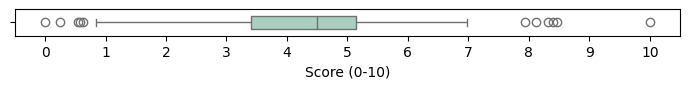

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set up the figure for overall performance
fig, ax = plt.subplots(1, 1, figsize=(7, 1), sharex=True, gridspec_kw={'height_ratios': [1], 'hspace': 0})

# Define colors
colors = ['#5DB692', '#B65D81']
#colors = ['#C4A54F', '#4F6EC4']
bar_color = colors[0]
boxplot_color_0 = sns.light_palette(bar_color, n_colors=3)[1]
boxplot_color_1 = sns.light_palette(bar_color, n_colors=3)[2]
density_color = colors[1]
boxplot_conf_color_0 = sns.light_palette(density_color, n_colors=3)[1]
boxplot_conf_color_1 = sns.light_palette(density_color, n_colors=3)[2]


# Plotting the horizontal boxplots for actual performance and expectations by treatment
sns.boxplot(x=ev['wa_difficulty'], ax=ax, color=boxplot_color_0, width=0.5)

ax.set_xlabel('Score (0-10)')
ax.set_xticks(range(11))
ax.set_xticklabels(range(11))

plt.tight_layout()

plt.show()

# Punishment

## Punishment treatment only

In [13]:
print(ttest_rel(ev[(ev['treat']==0)]['punish_del_bad'], ev[(ev['treat']==0)]['punish_nodel_bad']))
print(ttest_rel(ev[(ev['treat']==0) & (ev['pass_att2']==1)]['punish_del_bad'], ev[(ev['treat']==0) & (ev['pass_att2']==1)]['punish_nodel_bad']))

print(wilcoxon(ev[(ev['treat']==0)]['punish_del_bad'], ev[(ev['treat']==0)]['punish_nodel_bad']))
print(wilcoxon(ev[(ev['treat']==0) & (ev['pass_att2']==1)]['punish_del_bad'], ev[(ev['treat']==0) & (ev['pass_att2']==1)]['punish_nodel_bad']))

TtestResult(statistic=-1.526767996671881, pvalue=0.13081266190182173, df=79)
TtestResult(statistic=-1.447081336139677, pvalue=0.15260731503809388, df=66)
WilcoxonResult(statistic=203.0, pvalue=0.5436650715292322)
WilcoxonResult(statistic=151.0, pvalue=0.533314710033399)


## Hypothetical Punishment

In [16]:
ev.groupby('treat')[['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].mean()

,punish_del_good,punish_del_bad,punish_nodel_good,punish_nodel_bad
treat,,,,
0,0.329375,0.481875,0.29750,0.553125
1,0.228395,0.529630,0.22284,0.429012


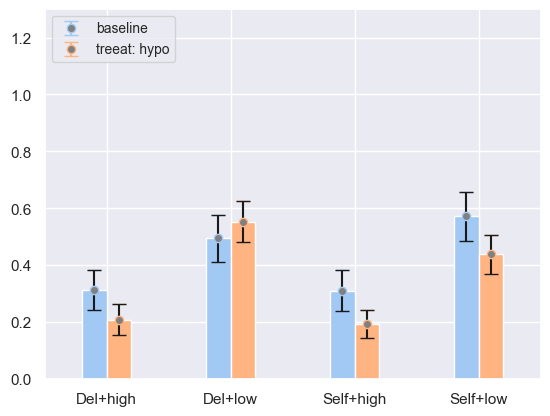

In [23]:
sns.set_theme()
sns.set_palette("pastel")

a=0.2 
t_all = ev[(ev['treat']==0) & (ev['pass_att2']==1)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
hypo = ev[(ev['treat']==1) & (ev['pass_att2']==1)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T

plt.errorbar([i-0.5*a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], fmt='o', capsize=5, label='baseline', markerfacecolor='grey')
plt.bar([i-0.5*a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], capsize=5, width=0.2)

plt.errorbar([i+0.5*a for i in [1, 2, 3, 4]], hypo['mean'], yerr=hypo['sem'], fmt='o', capsize=5, label='treeat: hypo', markerfacecolor='grey')
plt.bar([i+0.5*a for i in [1, 2, 3, 4]], hypo['mean'], yerr=hypo['sem'], capsize=5, width=0.2)

plt.xlim(0.5, 4.5)
plt.ylim(0, 1.3)
plt.xticks([1, 2, 3, 4], ['Del+high', 'Del+low', 'Self+high', 'Self+low'])
plt.legend(fontsize='small', loc='upper left')
plt.savefig('punish4.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
#full treat=1
ev[ev['treat']==1][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].describe()

,punish_del_good,punish_del_bad,punish_nodel_good,punish_nodel_bad
count,81.000000,81.000000,81.000000,81.000000
mean,0.228395,0.529630,0.222840,0.429012
std,0.445529,0.603364,0.426765,0.554012
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.250000,0.000000,0.100000
75%,0.200000,1.000000,0.100000,0.750000
max,2.000000,2.000000,2.000000,2.000000


In [17]:
print(ttest_rel(ev[(ev['treat']==1)]['punish_del_bad'], ev[(ev['treat']==1)]['punish_nodel_bad']))
print(ttest_rel(ev[(ev['treat']==1) & (ev['pass_att2']==1)]['punish_del_bad'], ev[(ev['treat']==1) & (ev['pass_att2']==1)]['punish_nodel_bad']))

print(wilcoxon(ev[(ev['treat']==1)]['punish_del_bad'], ev[(ev['treat']==1)]['punish_nodel_bad']))
print(wilcoxon(ev[(ev['treat']==1) & (ev['pass_att2']==1)]['punish_del_bad'], ev[(ev['treat']==1) & (ev['pass_att2']==1)]['punish_nodel_bad']))

TtestResult(statistic=1.842113689753299, pvalue=0.06916390237573936, df=80)
TtestResult(statistic=1.9829403220648045, pvalue=0.051475820570044704, df=67)
WilcoxonResult(statistic=123.0, pvalue=0.1124681112847182)
WilcoxonResult(statistic=87.0, pvalue=0.07161414625627813)


In [ ]:
#treat=1 and only those that punish
ev[(ev['never_punish']==0) & (ev['treat'] == 1)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].describe()

,punish_del_good,punish_del_bad,punish_nodel_good,punish_nodel_bad
count,52.000000,52.000000,52.000000,52.000000
mean,0.355769,0.825000,0.347115,0.668269
std,0.514939,0.567977,0.491637,0.564300
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.500000,0.000000,0.250000
50%,0.050000,1.000000,0.000000,0.500000
75%,0.662500,1.000000,0.925000,1.000000
max,2.000000,2.000000,2.000000,2.000000


In [ ]:
#treat=1 and only those that punish and not those that punish good more than bad regardless of delegation
ev[(ev['never_punish']==0) & (ev['treat'] == 1) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].describe()

,punish_del_good,punish_del_bad,punish_nodel_good,punish_nodel_bad
count,49.000000,49.000000,49.000000,49.000000
mean,0.303061,0.828571,0.312245,0.680612
std,0.477451,0.581127,0.484180,0.579225
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.500000,0.000000,0.250000
50%,0.000000,1.000000,0.000000,0.500000
75%,0.500000,1.000000,0.850000,1.000000
max,2.000000,2.000000,2.000000,2.000000


## Expected and real

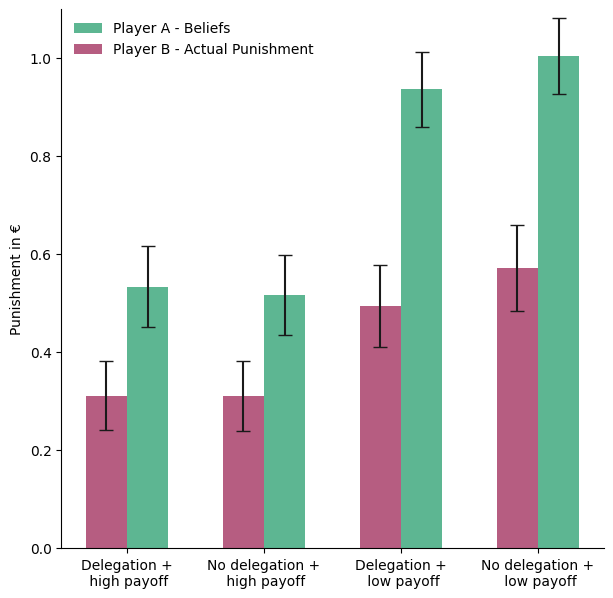

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib as mpl

mpl.style.use('default')

colors = ['#5DB692', '#B65D81']

ev2 = ev[(ev.treat==0) & (ev.pass_att2==1)].copy()
dg2 = dg[(dg.treat==0) & (dg.pass_att2==1)].copy()

# Calculate means and standard errors for each column in both dataframes
ev_means = [
    ev2['punish_del_good'].mean(),
    ev2['punish_nodel_good'].mean(),
    ev2['punish_del_bad'].mean(),
    ev2['punish_nodel_bad'].mean()
]

ev_sems = [
    ev2['punish_del_good'].sem(),
    ev2['punish_nodel_good'].sem(),
    ev2['punish_del_bad'].sem(),
    ev2['punish_nodel_bad'].sem()
]

dg_means = [
    dg2['belief_del_good'].mean(),
    dg2['belief_nodel_good'].mean(),
    dg2['belief_del_bad'].mean(),
    dg2['belief_nodel_bad'].mean()
]

dg_sems = [
    dg2['belief_del_good'].sem(),
    dg2['belief_nodel_good'].sem(),
    dg2['belief_del_bad'].sem(),
    dg2['belief_nodel_bad'].sem()
]

# Define labels for the scenarios
scenarios = ['del_good', 'nodel_good', 'del_bad', 'nodel_bad']

# Create a bar plot with customized figure size
x = range(len(scenarios))
width = 0.3  # Width of the bars

fig, ax = plt.subplots(figsize=(7, 7))  # Customize the figure size
ax.bar([p + width for p in x], dg_means, width, yerr=dg_sems, capsize=5, label='Player A - Beliefs', color=colors[0])
ax.bar(x, ev_means, width, yerr=ev_sems, capsize=5, label='Player B - Actual Punishment', color=colors[1])

# Labeling the plot
ax.set_ylabel('Punishment in \N{euro sign}')
ax.set_ylim(0, 1.1)
ax.set_xticks([p + width / 2 for p in x])
ax.set_xticklabels(['Delegation +\n high payoff', 'No delegation +\n high payoff', 'Delegation +\n low payoff', 'No delegation +\n low payoff'])
ax.legend(loc='upper left', frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.savefig("_outputs/punishment.png", bbox_inches="tight")

# Display the plot
plt.show()

In [31]:
print(ev[(ev.treat==0) & (ev.pass_att2==1)][['punish_del_good', 'punish_nodel_good', 'punish_del_bad', 'punish_nodel_bad']].mean())
print(ttest_rel(ev[(ev.treat==0) & (ev.pass_att2==1)]['punish_del_good'], ev[(ev.treat==0) & (ev.pass_att2==1)]['punish_nodel_good']))
print(ttest_rel(ev[(ev.treat==0) & (ev.pass_att2==1)]['punish_del_bad'], ev[(ev.treat==0) & (ev.pass_att2==1)]['punish_nodel_bad']))
print(wilcoxon(ev[(ev.treat==0) & (ev.pass_att2==1)]['punish_del_bad'], ev[(ev.treat==0) & (ev.pass_att2==1)]['punish_nodel_bad']))

punish_del_good      0.311194
punish_nodel_good    0.310448
punish_del_bad       0.494030
punish_nodel_bad     0.570896
dtype: float64
TtestResult(statistic=0.01415419326957903, pvalue=0.9887496645929568, df=66)
TtestResult(statistic=-1.447081336139677, pvalue=0.15260731503809388, df=66)
WilcoxonResult(statistic=151.0, pvalue=0.533314710033399)


## Frequency of punishment

In [32]:
ev[ev['treat']==0][['punish_del_good_binary', 'punish_del_bad_binary', 'punish_nodel_good_binary', 'punish_nodel_bad_binary']].describe()

,punish_del_good_binary,punish_del_bad_binary,punish_nodel_good_binary,punish_nodel_bad_binary
count,80.00000,80.000000,80.00000,80.000000
mean,0.32500,0.487500,0.32500,0.525000
std,0.47133,0.502997,0.47133,0.502525
min,0.00000,0.000000,0.00000,0.000000
25%,0.00000,0.000000,0.00000,0.000000
50%,0.00000,0.000000,0.00000,1.000000
75%,1.00000,1.000000,1.00000,1.000000
max,1.00000,1.000000,1.00000,1.000000


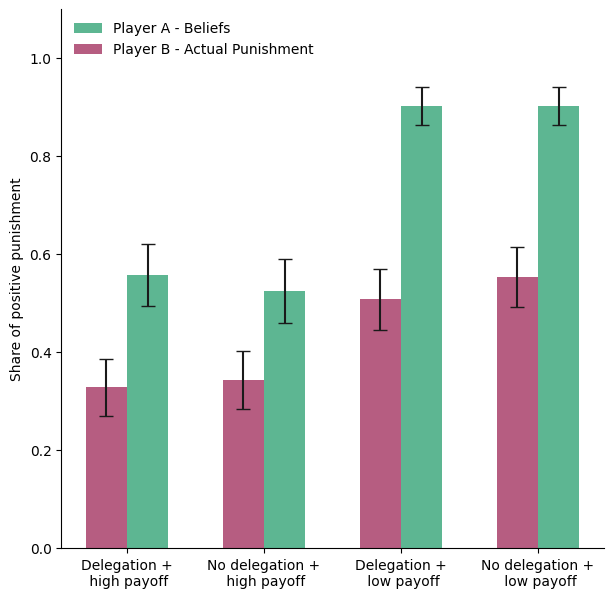

In [44]:
colors = ['#5DB692', '#B65D81']

ev2 = ev[(ev.treat==0) & (ev.pass_att2==1)].copy()
dg2 = dg[(dg.treat==0) & (dg.pass_att2==1)].copy()

# Calculate means and standard errors for each column in both dataframes
ev_means = [
    ev2['punish_del_good_binary'].mean(),
    ev2['punish_nodel_good_binary'].mean(),
    ev2['punish_del_bad_binary'].mean(),
    ev2['punish_nodel_bad_binary'].mean()
]

ev_sems = [
    ev2['punish_del_good_binary'].sem(),
    ev2['punish_nodel_good_binary'].sem(),
    ev2['punish_del_bad_binary'].sem(),
    ev2['punish_nodel_bad_binary'].sem()
]

dg_means = [
    dg2['belief_del_good_binary'].mean(),
    dg2['belief_nodel_good_binary'].mean(),
    dg2['belief_del_bad_binary'].mean(),
    dg2['belief_nodel_bad_binary'].mean()
]

dg_sems = [
    dg2['belief_del_good_binary'].sem(),
    dg2['belief_nodel_good_binary'].sem(),
    dg2['belief_del_bad_binary'].sem(),
    dg2['belief_nodel_bad_binary'].sem()
]

# Define labels for the scenarios
scenarios = ['del_good', 'nodel_good', 'del_bad', 'nodel_bad']

# Create a bar plot with customized figure size
x = range(len(scenarios))
width = 0.3  # Width of the bars

fig, ax = plt.subplots(figsize=(7, 7))  # Customize the figure size
ax.bar([p + width for p in x], dg_means, width, yerr=dg_sems, capsize=5, label='Player A - Beliefs', color=colors[0])
ax.bar(x, ev_means, width, yerr=ev_sems, capsize=5, label='Player B - Actual Punishment', color=colors[1])

# Labeling the plot
ax.set_ylabel('Share of positive punishment')
ax.set_ylim(0, 1.1)
ax.set_xticks([p + width / 2 for p in x])
ax.set_xticklabels(['Delegation +\n high payoff', 'No delegation +\n high payoff', 'Delegation +\n low payoff', 'No delegation +\n low payoff'])
ax.legend(loc='upper left', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("_outputs/punishment_shares.png", bbox_inches="tight")

# Display the plot
plt.show()

In [22]:
ev[(ev['treat']==0) & (ev['pass_att2']==1)]['never_punish'].mean()

np.float64(0.417910447761194)

# Punishment Correlations

In [36]:
ev[ev['treat']==0][['bad_good_del', 'bad_good_nodel', 'nodel_del_bad', 'nodel_del_good', 'wa_difficulty', 'med_difficulty', 'switching_point']].corr()

,bad_good_del,bad_good_nodel,nodel_del_bad,nodel_del_good,wa_difficulty,med_difficulty,switching_point
bad_good_del,1.000000,0.617964,-0.174136,0.154377,-0.039289,-0.078263,-0.239874
bad_good_nodel,0.617964,1.000000,0.288717,-0.389157,-0.041125,-0.069364,-0.245454
nodel_del_bad,-0.174136,0.288717,1.000000,0.315651,-0.039950,-0.129354,0.039453
nodel_del_good,0.154377,-0.389157,0.315651,1.000000,-0.025714,-0.113854,0.093971
wa_difficulty,-0.039289,-0.041125,-0.039950,-0.025714,1.000000,0.969893,-0.277367
med_difficulty,-0.078263,-0.069364,-0.129354,-0.113854,0.969893,1.000000,-0.266798
switching_point,-0.239874,-0.245454,0.039453,0.093971,-0.277367,-0.266798,1.000000


In [114]:
ev[ev['treat']==0][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad', 'wa_difficulty', 'med_difficulty', 'switching_point']].corr()

,punish_del_good,punish_del_bad,punish_nodel_good,punish_nodel_bad,wa_difficulty,med_difficulty,switching_point
punish_del_good,1.000000,0.670323,0.709530,0.590739,0.001424,0.042391,-0.012129
punish_del_bad,0.670323,1.000000,0.492467,0.826753,-0.029209,-0.022698,-0.197018
punish_nodel_good,0.709530,0.492467,1.000000,0.563438,-0.018609,-0.044580,0.060751
punish_nodel_bad,0.590739,0.826753,0.563438,1.000000,-0.050343,-0.095516,-0.162360
wa_difficulty,0.001424,-0.029209,-0.018609,-0.050343,1.000000,0.969893,-0.277367
med_difficulty,0.042391,-0.022698,-0.044580,-0.095516,0.969893,1.000000,-0.266798
switching_point,-0.012129,-0.197018,0.060751,-0.162360,-0.277367,-0.266798,1.000000


In [115]:
ev[(ev['treat']==0) & (ev['pass_att2']==1)][['nodel_del_bad', 'nodel_del_good', 'wa_difficulty', 'med_difficulty', 'switching_point']].corr()

,nodel_del_bad,nodel_del_good,wa_difficulty,med_difficulty,switching_point
nodel_del_bad,1.000000,0.529815,-0.037376,-0.149064,0.084363
nodel_del_good,0.529815,1.000000,-0.001231,-0.110920,-0.043231
wa_difficulty,-0.037376,-0.001231,1.000000,0.966518,-0.263972
med_difficulty,-0.149064,-0.110920,0.966518,1.000000,-0.213334
switching_point,0.084363,-0.043231,-0.263972,-0.213334,1.000000


In [129]:
ev[(ev['treat']==0) & (ev['p_time']>120)][['nodel_del_bad', 'nodel_del_good', 'wa_difficulty', 'med_difficulty', 'switching_point']].corr()

,nodel_del_bad,nodel_del_good,wa_difficulty,med_difficulty,switching_point
nodel_del_bad,1.000000,0.645589,0.314595,0.296795,0.020612
nodel_del_good,0.645589,1.000000,0.162532,0.140367,-0.007833
wa_difficulty,0.314595,0.162532,1.000000,0.981874,-0.293068
med_difficulty,0.296795,0.140367,0.981874,1.000000,-0.316003
switching_point,0.020612,-0.007833,-0.293068,-0.316003,1.000000


In [116]:
ev[(ev['pilot']==1)][['nodel_del_bad', 'nodel_del_good', 'wa_difficulty', 'med_difficulty', 'switching_point']].corr()

,nodel_del_bad,nodel_del_good,wa_difficulty,med_difficulty,switching_point
nodel_del_bad,1.000000,0.623189,-0.216924,-0.348026,0.161250
nodel_del_good,0.623189,1.000000,-0.111885,-0.283275,0.031122
wa_difficulty,-0.216924,-0.111885,1.000000,0.970573,-0.363575
med_difficulty,-0.348026,-0.283275,0.970573,1.000000,-0.332267
switching_point,0.161250,0.031122,-0.363575,-0.332267,1.000000


## Order effects

no order effect

In [78]:
ev[['treat', 'eva.id_in_group', 'punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].groupby(['treat', 'eva.id_in_group']).mean()

punish_del_good  punish_del_bad  punish_nodel_good  \
treat eva.id_in_group                                                       
0     1                       0.320732        0.423171           0.247561   
      2                       0.338462        0.543590           0.350000   
1     1                       0.241026        0.580769           0.219231   
      2                       0.216667        0.482143           0.226190   

                       punish_nodel_bad  
treat eva.id_in_group                    
0     1                        0.578049  
      2                        0.526923  
1     1                        0.515385  
      2                        0.348810

In [17]:
ev[ev['treat']==1].shape

(81, 82)

# Regressions

In [16]:
#choose dependent variable
dep1=['nodel_del_bad']
dep2=['nodel_del_good']

socio_demographics = ['technology_score', 'went_to_uni', 'leader', 'tech_use_at_work_often', 'age', 'female', 'socio_status']

datasets = [ev[(ev['treat']==0) & (ev['pass_att2']==1)]]

model_summaries = []
models = {
    "model1": [dep1, ['med_difficulty']],
    "model2": [dep1, ['med_difficulty'] + socio_demographics],
    "model4": [dep1, ['switching_point']],
    "model5": [dep2, ['med_difficulty']],
    "model6": [dep2, ['med_difficulty'] + socio_demographics],
    "model7": [dep2, ['switching_point']],
}

list_of_reg_results = []
for data in datasets:
    for key in models.keys():
        est = sm.OLS(endog=data[models[key][0]], exog=sm.add_constant(data[models[key][1]]), missing='drop').fit()
        list_of_reg_results.append(est)

model_summary = Stargazer(list_of_reg_results)
model_summary.custom_columns(['bad', 'good'], [3, 3])
model_summary.covariate_order(["const", 'med_difficulty', 'switching_point'] + socio_demographics)
model_summary.show_degrees_of_freedom(False)
model_summaries.append(model_summary)

model_summaries[0]

In [13]:
model_summaries[1]

In [92]:
#choose dependent variable
dep_vars=['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad', 'bad_good_del', 'bad_good_nodel', 'nodel_del_bad', 'nodel_del_good']

datasets = [ev, ev[ev['treat']==0], ev[ev['never_punish']==0], ev[(ev['treat']==0) & (ev['never_punish']==0)]]

model_summaries = []
for dep in dep_vars:
    #create dictionary with all regression models in the following form "name of model": ["dependent var", [list of regressors]],
    models = {
        "model1": [dep, ['wa_difficulty']],
        "model2": [dep, ['female']],
        "model3": [dep, ['Age']],
        "model4": [dep, ['switching_point']],
    }
    
    list_of_reg_results = []
    for data in datasets:
        for key in models.keys():
            est = sm.OLS(endog=data[models[key][0]], exog=sm.add_constant(data[models[key][1]]), missing='drop').fit()
            list_of_reg_results.append(est)

    model_summary = Stargazer(list_of_reg_results)
    model_summary.custom_columns(['full', 'treat=0', 'positive punish', 'treat=0 and positive punish'], [4, 4, 4, 4])
    model_summary.covariate_order(["const", 'wa_difficulty', 'female', 'Age', 'switching_point'])
    model_summary.show_degrees_of_freedom(False)
    model_summaries.append(model_summary)

model_summaries[0]

In [93]:
model_summaries[1]

In [94]:
model_summaries[2]

In [95]:
model_summaries[3]

In [96]:
model_summaries[4]

In [97]:
model_summaries[5]

In [98]:
model_summaries[6]

In [115]:
model_summaries[7]

In [93]:
est = []

for d in [ev, ev[ev['treat']==0]]:
    param_specs = [
        ['wa_difficulty'],
        ['female'],
        ['Age'],
        ['switching_point']
    ]

    
    for i in param_specs:
        l = i.copy()
        l.append('nodel_del_bad')

        reg = d[l].copy()
        reg = reg.dropna()
        Y = reg['nodel_del_bad']
        X = sm.add_constant(reg[i])
        model = sm.OLS(Y.astype(float),X.astype(float)).fit()
        est.append(model)
stargazer = Stargazer(est)
stargazer.custom_columns(['All observations', 'treat=0'], [4, 4])
stargazer.significant_digits(2)
stargazer.covariate_order(['const', 'wa_difficulty', 'female', 'Age', 'switching_point'])
stargazer.show_degrees_of_freedom(False)

stargazer